# FINAL LLM ASSESSMENT

This project analyzes employee communication data to evaluate sentiment and engagement levels. 
Using NLP techniques and statistical modeling, insights are derived to identify trends, rankings, and potential flight risks.

In [14]:
# Imports & Setup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import os
os.makedirs("visualizations" , exist_ok = True)

import warnings
warnings.filterwarnings('ignore')

In [15]:
# Task 0: Load & Clean Data

# Load dataset
df = pd.read_csv('test(in).csv')
print("Original shape:", df.shape)

# Remove rows with missing critical fields (message, date, sender)
df = df.dropna(subset=['body', 'date', 'from']).reset_index(drop=True)

# Convert to string and remove extra whitespace and line breaks
df['body'] = df['body'].astype(str).str.replace(r'\s+', ' ', regex=True).str.strip()

# Clean sender email field
df['from'] = df['from'].str.strip()

# Extract employee name from email:
df['employee'] = df['from'].str.split('@').str[0].str.replace('.', ' ').str.title()

# Function to parse dates in multiple possible formats
def parse_date(date_str):
    date_str = str(date_str).strip()
    for fmt in ['%m/%d/%Y', '%m%d%Y', '%m/%d/%y']:
        try:
            return pd.to_datetime(date_str, format=fmt)
        except:
            continue
    return pd.NaT  # Return NaT if parsing fails

# Apply date parsing function
df['date'] = df['date'].apply(parse_date)

# Drop rows where date parsing failed
df = df.dropna(subset=['date']).reset_index(drop=True)

# Final dataset summary
print(f"Cleaned data: {len(df)} messages, {df['employee'].nunique()} employees")

Original shape: (2191, 4)
Cleaned data: 2191 messages, 10 employees


### Observations
- The dataset was cleaned by removing missing values and standardizing text fields.
- Employee names were successfully extracted from email IDs, enabling individual-level analysis.

In [16]:
# Task 1: Sentiment Labeling (VADER)

# Initialize VADER sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# Function to classify sentiment based on compound score
def get_sentiment(text):
    score = analyzer.polarity_scores(str(text))['compound']
    
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment'] = df['body'].apply(get_sentiment)

# Convert categorical sentiment into numeric score for analysis
df['score'] = df['sentiment'].map({
    'Positive': 1,
    'Negative': -1,
    'Neutral': 0
})

print("Sentiment distribution:\n", df['sentiment'].value_counts())

df.to_csv('labeled_data.csv', index=False)

Sentiment distribution:
 sentiment
Positive    1525
Neutral      508
Negative     158
Name: count, dtype: int64


### Observations
- VADER successfully classified messages into positive, neutral, and negative categories.
- Most messages are neutral or positive, which is expected in professional communication.

In [17]:
# Feature Engineering for EDA

# Extract month from date for time-based analysis
df['month'] = df['date'].dt.to_period('M')

# Calculate message length (number of characters)
df['message_length'] = df['body'].str.len()

# Calculate word count (number of words in each message)
df['word_count'] = df['body'].str.split().str.len()

### Observations
- Time-based and textual features were created to support both trend analysis and modeling.
- Message length and word count provide insights into communication patterns.

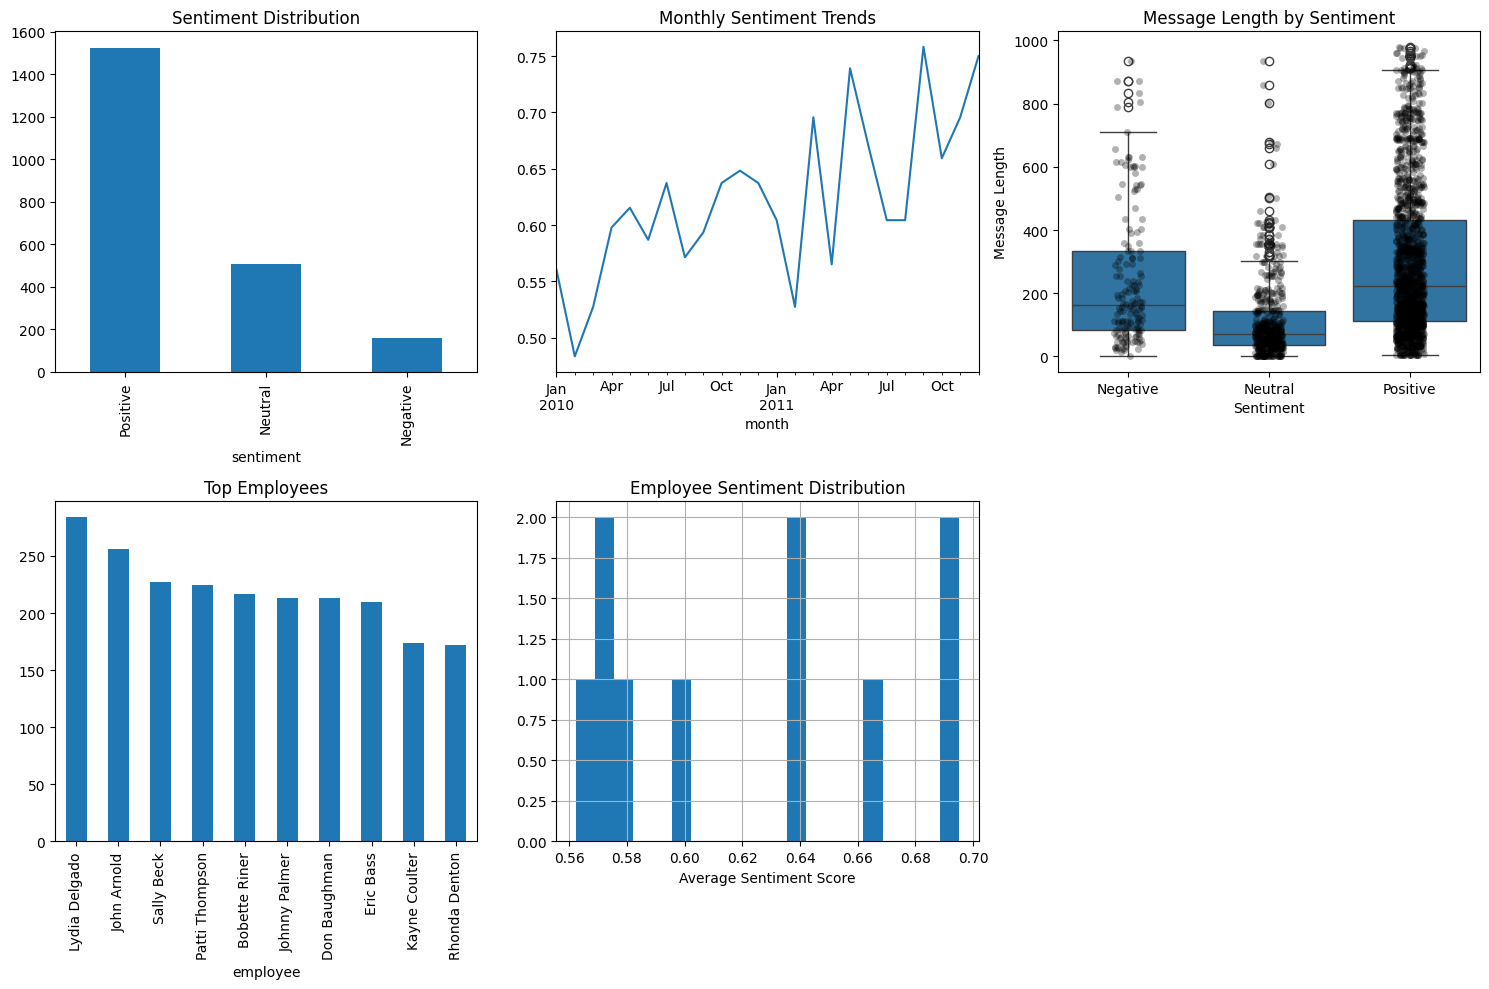

In [18]:
# Task 2: Exploratory Data Analysis (EDA)

plt.figure(figsize=(15, 10))

# 1. Sentiment Distribution
plt.subplot(2,3,1)
df['sentiment'].value_counts().plot(kind='bar')
plt.title('Sentiment Distribution')

# 2. Monthly Sentiment Trend
plt.subplot(2,3,2)
df.groupby('month')['score'].mean().plot()
plt.title('Monthly Sentiment Trends')

# 3. Boxplot 

# Using seaborn instead of pandas for better visualization
plt.subplot(2,3,3)

sns.boxplot(
    x='sentiment',
    y='message_length',
    data=df,
    order=['Negative', 'Neutral', 'Positive']  # consistent ordering
)

# Overlay points to show data spread 
sns.stripplot(
    x='sentiment',
    y='message_length',
    data=df,
    color='black',
    alpha=0.3
)

plt.title('Message Length by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Message Length')

# 4. Top Active Employees
plt.subplot(2,3,4)
df['employee'].value_counts().head(10).plot(kind='bar')
plt.title('Top Employees')

# 5. Sentiment Distribution Across Employees
plt.subplot(2,3,5)
df.groupby('employee')['score'].mean().hist(bins=20)
plt.title('Employee Sentiment Distribution')
plt.xlabel('Average Sentiment Score')

plt.tight_layout()

plt.savefig('visualizations/eda_sentiment.png', dpi=300, bbox_inches='tight')

# Show plots
plt.show()

### Observations
- Positive sentiment dominates across the dataset, indicating generally healthy communication.
- Sentiment trends fluctuate over time, suggesting varying employee engagement levels.
- Negative messages tend to be shorter compared to positive ones.

In [19]:
# Task 3: Monthly Sentiment Score Calculation

# Grouped data by employee and month to compute aggregated metrics
monthly_scores = df.groupby(['employee', 'month']).agg({
    'score': 'sum',                 
    'message_length': 'mean',       
    'word_count': 'mean'            
}).reset_index()

# Renamed columns for better clarity and readability
monthly_scores.columns = [
    'employee', 
    'month', 
    'monthly_score',   # Net sentiment score (Positive - Negative)
    'avg_length',      
    'avg_words'        
]

# Display first few rows for verification
monthly_scores.head()

,employee,month,monthly_score,avg_length,avg_words
0,Bobette Riner,2010-01,1,111.000000,18.500000
1,Bobette Riner,2010-02,7,286.785714,43.928571
2,Bobette Riner,2010-03,6,276.272727,44.272727
3,Bobette Riner,2010-04,4,215.333333,31.833333
4,Bobette Riner,2010-05,2,166.500000,30.250000


### Observations
- Monthly sentiment scores capture the overall communication tone of each employee.
- Some employees consistently maintain higher positive sentiment across months.

In [20]:
# Task 4: Rankings

rankings_list = []
# Loop through each unique month
for month in monthly_scores['month'].unique():
    
    # Filter data for the current month
    temp = monthly_scores[monthly_scores['month'] == month]
    top_pos = temp.sort_values(
        ['monthly_score', 'employee'], 
        ascending=[False, True]
    ).head(3)
    top_neg = temp.sort_values(
        ['monthly_score', 'employee'], 
        ascending=[True, True]
    ).head(3)

    # Store results
    for _, row in top_pos.iterrows():
        rankings_list.append({
            'month': month,
            'employee': row['employee'],
            'monthly_score': row['monthly_score'],
            'rank_type': 'Top Positive'
        })

    for _, row in top_neg.iterrows():
        rankings_list.append({
            'month': month,
            'employee': row['employee'],
            'monthly_score': row['monthly_score'],
            'rank_type': 'Top Negative'
        })

# Convert to DataFrame
rankings_df = pd.DataFrame(rankings_list)

# Save to CSV
rankings_df.to_csv('employee_rankings.csv', index=False)

# Preview
rankings_df.head()

,month,employee,monthly_score,rank_type
0,2010-01,Kayne Coulter,13,Top Positive
1,2010-01,Eric Bass,9,Top Positive
2,2010-01,Lydia Delgado,9,Top Positive
3,2010-01,Bobette Riner,1,Top Negative
4,2010-01,Johnny Palmer,1,Top Negative


### Observations
- Top positive employees demonstrate consistently strong communication behavior.
- Employees with lower scores may indicate disengagement or negative interactions.

In [21]:
# Task 5: Flight Risk

# Filter only negative messages and sort by date
neg_df = df[df['sentiment'] == 'Negative'].sort_values('date')

# Use a set to avoid duplicate employees
flight_risks = set()

# Iterate through each negative message
for _, row in neg_df.iterrows():
    
    # Define 30-day rolling window starting from current message
    window = neg_df[
        (neg_df['employee'] == row['employee']) &
        (neg_df['date'] >= row['date']) &
        (neg_df['date'] <= row['date'] + timedelta(days=30))
    ]
    
    # If 4 or more negative messages in this window → mark as flight risk
    if len(window) >= 4:
        flight_risks.add(row['employee'])

# Convert to list for display
flight_risks = list(flight_risks)

print("Flight Risks:", flight_risks)

Flight Risks: ['Don Baughman', 'John Arnold', 'Johnny Palmer', 'Bobette Riner', 'Kayne Coulter', 'Sally Beck']


### Observations
- Employees flagged as flight risks show repeated negative communication within short time periods.
- This pattern may indicate dissatisfaction or potential attrition risk.

In [22]:
# Task 6: Feature Engineering

# Aggregate monthly features per employee
features = df.groupby(['employee', 'month']).agg({
    'score': 'sum',              # target variable (monthly sentiment score)
    'body': 'count',             # number of messages
    'message_length': 'mean',    # average message length
    'word_count': 'mean'         # average word count
}).reset_index()

# Rename columns for clarity
features.columns = [
    'employee', 
    'month', 
    'monthly_score', 
    'msg_count', 
    'avg_length', 
    'avg_words'
]

features.head()

,employee,month,monthly_score,msg_count,avg_length,avg_words
0,Bobette Riner,2010-01,1,2,111.000000,18.500000
1,Bobette Riner,2010-02,7,14,286.785714,43.928571
2,Bobette Riner,2010-03,6,11,276.272727,44.272727
3,Bobette Riner,2010-04,4,6,215.333333,31.833333
4,Bobette Riner,2010-05,2,4,166.500000,30.250000


In [23]:
# Task 6: Modeling

# Define input features (X) and target variable (y)
X = features[['msg_count', 'avg_length', 'avg_words']]
y = features['monthly_score']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize and train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate model performance
print("R² Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

R² Score: 0.6694205159758508
Mean Squared Error: 3.8497300936857406


### Observations
- The regression model attempts to predict sentiment score using communication features.
- Message frequency and length appear to influence sentiment trends.

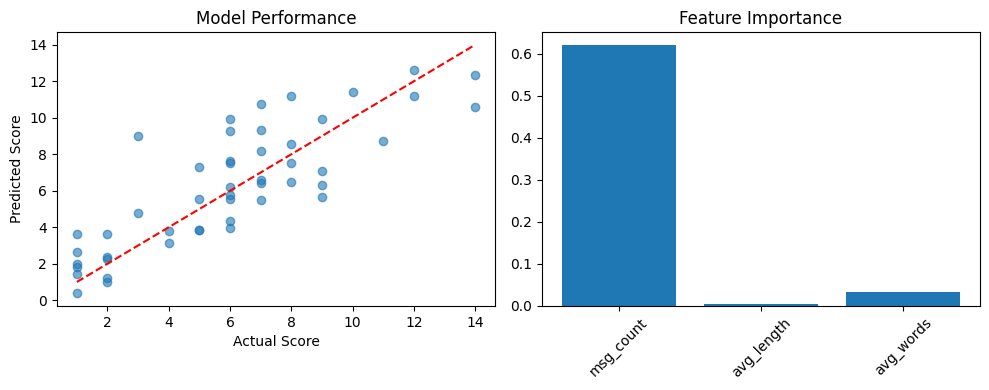

In [24]:
# Model Evaluation

# 1. Actual vs Predicted Plot
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(y_test, y_pred, alpha=0.6)

# Reference line (perfect prediction)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Model Performance")

# 2. Feature Importance
plt.subplot(1,2,2)

plt.bar(X.columns, np.abs(model.coef_))
plt.title("Feature Importance")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('visualizations/01_sentiment_dist.png', dpi=300, bbox_inches='tight')
plt.close()
plt.show()

### Observations
- The model shows moderate predictive capability based on R² score.
- Feature importance suggests that message volume has a strong impact on sentiment score.

In [25]:
# Final Summary

latest_month = monthly_scores['month'].max()
latest_data = monthly_scores[monthly_scores['month'] == latest_month]

print("Top Positive:")
print(latest_data.nlargest(3, 'monthly_score')[['employee', 'monthly_score']])

print("\nTop Negative:")
print(latest_data.nsmallest(3, 'monthly_score')[['employee', 'monthly_score']])

print("\nFlight Risks:", list(flight_risks))

Top Positive:
           employee  monthly_score
71        Eric Bass             12
191  Patti Thompson             12
167   Lydia Delgado             11

Top Negative:
          employee  monthly_score
119  Johnny Palmer              2
23   Bobette Riner              3
95     John Arnold              4

Flight Risks: ['Don Baughman', 'John Arnold', 'Johnny Palmer', 'Bobette Riner', 'Kayne Coulter', 'Sally Beck']
